In [1]:
import os
import pandas as pd
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import ast
import numpy as np
plt.style.use('tableau-colorblind10')
from matplotlib.lines import Line2D

colors_blind=['#006BA4', '#FF800E', '#ABABAB', '#595959',
                 '#5F9ED1', '#C85200', '#898989', '#A2C8EC', '#FFBC79', '#CFCFCF']
from Plotting_base_code import plotting_pytorch as plotting
from CNN_code import cnn_create


/home/simrank/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
class plot:
    def __init__(self):
        self.x_fontsize_label=25
        self.y_fontsize_label=20
        self.x_fontsize=10
        self.y_fontsize=10
        
        self.size_prop=15

        self.row=7
        self.col=5
        self.t_fontsize=15
        self.title_font=13

        self.figure_size=(20,25)
        # figure_size=(10,12)
        self.rotation=30
        self.w_space=0.1
        self.h_space=0.1
        self.markersize=5
        self.label_text='% corruption degree'
        self.x_label='Epoch'
        self.pad_value=10
        self.corruption=[0.0,0.2,0.4,0.6,0.8,1.0]
        
 
    def divide_function(self,list_value,int_value):
        newList = []
        for x in list_value:
            newList.append(x/int_value)
        return newList
    def print_x_axis(self,values_xaxis):
        x_labels = list(map(int, values_xaxis))  
        max_val = max(x_labels)

        # Decide step size adaptively
        if max_val <= 40:
            tick_labels = list(range(0, max_val + 1, 10))
        elif max_val >= 300:
            tick_labels = list(range(0, max_val + 1, 80))
        else:
            tick_labels = list(range(0, max_val + 1, 40))

        # Find closest indices in x_labels for each desired tick
        tick_indices = [min(range(len(x_labels)), key=lambda i: abs(x_labels[i] - val))
                        for val in tick_labels if val <= max_val]

        return tick_labels, tick_indices, x_labels


        
    def accuracy_model(self,type_acc,data_name,corrupt,tiny=False):
        if data_name=='Testing':
            data='Test_accuracy'
        run=[]
        for run_type in range(1,4,1):
            if tiny:
                num_epoch,min_epoch=plotting.final_epoch_tiny(corrupt,run_type)
                x_acc=[i for i in range(-1,min_epoch,1)]+[num_epoch]
                x_acc[0]=0
                if corrupt==0.8 or corrupt==1.0:
                    models_load=cnn_create.select_model(x_acc,tiny)
                else:
                    models_load=cnn_create.select_model(x_acc,tiny)+[x_acc[-1]-1]        
                run.append(self.divide_function(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                                           .sort_values(by='epoch')[data]
                                           [models_load].tolist(),100))
            else:
                
                num_epoch=(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                           .sort_values(by='epoch')['epoch']).tolist()[-1]
                x_acc=[i for i in range(-1,num_epoch,1)]
                x_acc[0]=0
                run.append(self.divide_function(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                                           .sort_values(by='epoch')[data]
                                           [cnn_create.select_model(x_acc,tiny)].tolist(),100))
   
        return run
    

    
    def layer_info(self,network,dropout):
        if network=='ResNet18':
            if dropout:
                labels_names = ['Model test accuracy','L2','L3',
                                'L4','Avg_pool','Dropout'] #
                data_layer_name = ['l2','l3','l4','bf_last','after_dropout']#
            else:
                labels_names = ['Model test accuracy','L2','L3',
                                'L4','Avg_pool'] #
                data_layer_name = ['l2','l3','l4','bf_last']#
        else:
            if dropout:
                labels_names=[f'Model test accuracy',
                  'Flat (576/1024)',
                  'FC1-Dropout','FC2-Dropout','FC3-Dropout']    
                #'Input',  'FC1 (250)', 'FC2 (250)', 'FC3 (250)',

                data_layer_name=['flattern','fc1_dropout','fc2_dropout','fc3_dropout']
                #'input','fc1','fc2','fc3',
            else:
                labels_names=[f'Model test accuracy',
                  'Flat (576/1024)',
                  'FC1 (250)','FC2 (250)','FC3 (250)']    #'Input',    

                data_layer_name=['flattern','fc1','fc2','fc3']#'input',
        return labels_names,data_layer_name

    
    
    def folder_results(self,resfoldername, fold_type):
        
        os.makedirs(f'{resfoldername}',exist_ok=True)
        os.makedirs(f'{resfoldername}/{fold_type}',exist_ok=True)
        os.makedirs(f'{resfoldername}/{fold_type}/pdf',exist_ok=True)
        os.makedirs(f'{resfoldername}/{fold_type}/png',exist_ok=True)

        result1=f'{resfoldername}/{fold_type}/pdf'
        result2=f'{resfoldername}/{fold_type}/png'
        
        return [result1 , result2]
           
    
    def accuracy_model_all(self,type_acc,data_name,corrupt,tiny=False):
        run=[]
        if data_name=='Corrupted Training':
            data='Train_accuracy'

        if data_name=='Testing':
            data='Test_accuracy'

        for run_type in ['Run_1','Run_2','Run_3']:

            num_epoch=(pd.read_csv(f'{type_acc}/{run_type}.csv')
                       .sort_values(by='epoch')['epoch']).tolist()[-1]
            x_acc=[i for i in range(-1,num_epoch,1)]
            x_acc[0]=0

            if data_name=='Original Training':
                if corrupt ==0.0:
                    data='Train_accuracy'
                    run.append(self.divide_function(pd.read_csv(f'{type_acc}/{run_type}.csv')
                                               .sort_values(by='epoch')[data]
                                               [cnn_create.select_model(x_acc,tiny)].tolist(),100))
                else:
                    data='Train_accuracy_org'
                    run.append(self.divide_function(pd.read_csv(f'{type_acc}/{run_type}_org.csv')
                                               .sort_values(by='epoch')[data]
                                               [cnn_create.select_model(x_acc,tiny)].tolist(),100))

            else:
                run.append(self.divide_function(pd.read_csv(f'{type_acc}/{run_type}.csv')
                                               .sort_values(by='epoch')[data]
                                               [cnn_create.select_model(x_acc,tiny)].tolist(),100))

        return run
    

    
    def path_dropout_ResNet18(self,network,data_type,corrupt,n,mavc=False,dropout=False):
        if dropout:
            if mavc:
                typex=f'../TMLR_Dropout/results_velpic/40/angle_results_{n}/{data_type}_{network}_dropout/results_{corrupt}'
            else:
                typex=f'../TMLR_Dropout/results/40/angle_results_{n}/{data_type}_{network}_dropout/results_{corrupt}'
            type_acc=f'../TMLR_Dropout/models/{data_type}_{network}_dropout/Accuracy_results/{corrupt}'    
        else:
            if mavc:
                typex=f'../TMLR_ResNet18_during_training/results_velpic/40/angle_results_{n}/{data_type}_{network}/results_{corrupt}'
            else:
                typex=f'../TMLR_ResNet18_during_training/results/40/angle_results_{n}/{data_type}_{network}/results_{corrupt}'
            type_acc=f'../../TMLR_compare/Modern_backbones/models/{data_type}_{network}/Accuracy_results/{corrupt}'
    
        return typex,type_acc
    
    def path_dropout_CNN(self,network,data_type,corrupt,n,mavc=False,dropout=False):
        if dropout:
            if mavc:
                typex=f'../TMLR_Dropout/results_velpic/40/angle_results_{n}/{data_type}_{network}_dropout/results_{corrupt}'
            else:
                typex=f'../TMLR_Dropout/results/40/angle_results_{n}/{data_type}_{network}_dropout/results_{corrupt}'
            type_acc=f'../TMLR_Dropout/models/{data_type}_{network}_dropout/Accuracy_results/{corrupt}'    
        else:
            if mavc:
                typex=f'../pca_during_training_angle/angle_results_1pc/{data_type}_{network}/results_{corrupt}'
            else:
                typex=f'../pca_during_training_angle/angle_results/{data_type}_{network}/results_{corrupt}'
            type_acc=f'../pca_during_training_angle/angle_results/{data_type}_{network}/Accuracy_results/{corrupt}'
        return typex,type_acc
    
    

In [3]:
class plot_drop(plot):
    def subtract_list(self,list1,list2):
        result = []
        for i in range(len(list1)):
            result.append(list1[i] - list2[i])

        return result

    def read_file_name(self,data_name,type_cnn,folder_name,run,model_number,layer):
        file_name=f'{type_cnn}/{folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_test.csv'
        return file_name
    
    
    def main_appendix(self,subspace_type,data_name,n):
        networks=['CNN','CNN','CNN']
        data_types=['MNIST','FashionMNIST','CIFAR10']
        return networks,data_types
    
    def accuracy_model(self,type_acc,data_name,corrupt,tiny=False):

        if data_name=='Testing':
            data='Test_accuracy'
        run=[]
        for run_type in range(1,4,1):

                
            num_epoch=(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                       .sort_values(by='epoch')['epoch']).tolist()[-1]
            x_acc=[i for i in range(-1,num_epoch,1)]
            x_acc[0]=0
            run.append(self.divide_function(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                                       .sort_values(by='epoch')[data]
                                       [cnn_create.select_model(x_acc,tiny)].tolist(),100))
   
        return run

    def accuracy_model_one_run(self,type_acc,data_name,corrupt,tiny=False):

        if data_name=='Testing':
            data='Test_accuracy'
        run=[]
        run_type=1
#         for run_type in range(1,4,1):

                
        num_epoch=(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                   .sort_values(by='epoch')['epoch']).tolist()[-1]
        x_acc=[i for i in range(-1,num_epoch,1)]
        x_acc[0]=0
        run.append(self.divide_function(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                                   .sort_values(by='epoch')[data]
                                   [cnn_create.select_model(x_acc,tiny)].tolist(),100))
   
        return run

    def epoch_all_accuracy_one_run(self,path_x_values,tiny=False):
        len_x_run=[]
        last_values_xaxis=[]
        run_type=1
        
        path_model_num=f'{path_x_values}/angle_results/Run_{run_type}/'
        len_x_run.append(len(os.listdir(path_model_num)))
        if tiny:
            last_values_xaxis.append(sorted(os.listdir(path_model_num),key=int)[-1])


        len_x=min(len_x_run)
        ind_len=len_x_run.index(len_x)                     
        path_model=f'{path_x_values}/angle_results/Run_{ind_len+1}/'      
        if tiny:
            values_xaxis=sorted(os.listdir(path_model),key=int)[:-1]
            values_xaxis=values_xaxis+last_values_xaxis
        else:
            values_xaxis=sorted(os.listdir(path_model),key=int)

        x=[i for i in range(len_x)]
        return values_xaxis,x
    def plot_dropout(self,resfoldername,masc,corruptions):
        train=True

        data_name='Testing'
        name_title='Test'
        subspace_type='corrupt'
        folder_name='angle_results'


        fold_type='dropout'
        result1,result2=self.folder_results(resfoldername,fold_type)
        if masc:
            y_label=f'MASC {name_title} Accuracy'
        else:
            y_label=f'VeLPIC {name_title} Accuracy'

        if corruptions:
            self.corruption=[0.2,0.4,0.6,0.8]
            name_2='2_8'
            self.figure_size=(20,21)
            self.y_fontsize_label=30
            self.col=4
        else:
            self.corruption=[0.0]#1.0.
            name_2='0' 
            self.figure_size=(20,25)
            self.y_fontsize_label=30
            self.col=1
        self.row=8
#         labels_names_total=[f'Model test accuracy','ResNet-18-L2 (8192)',
#                             'ResNet-18-L3 (4096)','ResNet-18-L4 (2048)',
#                             'ResNet-18-Avg_pool (512)','ResNet-18-Dropout'] 
        #
        labels_names_total=[f'Model test accuracy','CNN-Flat (576/1024)',
                            'CNN-FC1 (250)/ CNN-FC1-Dropout',
                            'CNN-FC2 (250)/ CNN-FC2-Dropout/ ResNet-18-L2 (8192)',
                            'CNN-FC3 (250)/ CNN-FC3-Dropout/ ResNet-18-L3 (4096)',
                            ' ResNet-18-L4 (2048)',
                            ' ResNet-18-Avg_pool (512)',' ResNet-18-Dropout'] 
        if masc==True:
            mavc=False
            n=0.99
        else:
            mavc=True
            n=1
                
        file_final_name=f'ACCURACY_{subspace_type}_{data_name}_{n}_all'
        custom_colors=[colors_blind[0],colors_blind[2],
                       colors_blind[3],colors_blind[4],
                       colors_blind[5],colors_blind[6],
                       colors_blind[8],colors_blind[9],
                       colors_blind[3]]#
        line_styles = [':', '-', '-', '-', '-', '-', '-', '-', '-'] 
        fig = plt.figure(figsize=self.figure_size)
        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=self.w_space, hspace=self.h_space)

        count=1

        for dropout in [False,True]:#
            network='ResNet18'
            data_type='CIFAR10' 
            for corrupt in self.corruption:
                if corrupt==1.0:
                    continue
                labels_names,data_layer_name=self.layer_info(network,dropout)
  
                type_cnn,type_acc=self.path_dropout_ResNet18(network,data_type,corrupt,n,mavc,dropout)
                print(type_cnn)

                fig.add_subplot(self.row, self.col,count)

                run_acc=self.accuracy_model(type_acc,data_name,corrupt)
                values_xaxis,x=plotting.epoch_all_accuracy(type_cnn)
                tick_labels,tick_indices,x_labels=self.print_x_axis(values_xaxis)            

                max_value,min_value,avg_value=plotting.fun_1(run_acc)
                len_avg=len(avg_value)

                max_value[0]=0.10
                min_value[0]=0.10
                avg_value[0]=0.10
                plt.plot(x_labels[:len_avg],avg_value,':',markersize=self.markersize,
                         label=labels_names[0],color=colors_blind[0])
                plt.fill_between(x_labels[:len_avg],min_value, max_value, alpha=.2,label='_nolegend_',color=colors_blind[0])
                color_count=4
                for layer,labels_name in zip(data_layer_name,labels_names[1:]):

                    run_layer=[]
                    for run in range(1,4):
                        run_value=[]
                        for model_number in values_xaxis:
                            run_value.append(pd.read_csv(f'{type_cnn}/{folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0])

                        run_layer.append(run_value)
                    max_value,min_value,avg_value=plotting.fun_1(run_layer)
                    plt.plot(x_labels[:len_avg],avg_value,markersize=self.markersize,label=labels_name,color=colors_blind[color_count])
                    plt.fill_between(x_labels[:len_avg],min_value, max_value, alpha=.2,label='_nolegend_',
                                     color=colors_blind[color_count])
                    plt.yticks(fontsize= self.y_fontsize)
                    plt.xticks([x_labels[i] for i in tick_indices])

                    if color_count==6:
                        color_count=color_count+2
                    else:
                        color_count=color_count+1
                if (count - 1) % self.col == 0:  
                    if dropout:
                        y_text=f'ResNet-18-WD-{plotting.get_datasetname(data_type)}'
                    else:
                        y_text=f'ResNet-18-{plotting.get_datasetname(data_type)}'
                    plt.ylabel(y_text,
                               fontsize=self.title_font)
                if count<= self.col:
                    plt.title(f'{plotting.get_corrupt(corrupt)}{self.label_text}',
                              fontsize=self.t_fontsize,pad=self.pad_value)

                plt.ylim(-0.01,1.01)
                
                count=count+1
        
              
        networks,data_types=self.main_appendix(subspace_type,data_name,n)
        for network,data_type in zip(networks,data_types):
            dropout=False  
            
            for corrupt in self.corruption:

                labels_names,data_layer_name=self.layer_info(network,dropout)

                type_cnn,type_acc=self.path_dropout_CNN(network,data_type,corrupt,n,mavc,dropout)
                print(type_cnn)
                fig.add_subplot(self.row, self.col,count)

                run_acc=self.accuracy_model(type_acc,data_name,corrupt)
                values_xaxis,x=plotting.epoch_all_accuracy(type_cnn)
                tick_labels,tick_indices,x_labels=self.print_x_axis(values_xaxis)            

                max_value,min_value,avg_value=plotting.fun_1(run_acc)
                len_avg=len(avg_value)

                max_value[0]=0.10
                min_value[0]=0.10
                avg_value[0]=0.10
                plt.plot(x_labels[:len_avg],avg_value,':',markersize=self.markersize,
                         label=labels_names[0],color=colors_blind[0])
                plt.fill_between(x_labels[:len_avg],min_value, max_value, alpha=.2,label='_nolegend_',color=colors_blind[0])
                color_count=2
                for layer,labels_name in zip(data_layer_name,labels_names[1:]):
                    run_layer=[]
                    for run in range(1,4):
                        run_value=[]
                        for model_number in values_xaxis:
                            if data_name == 'Testing' :
                                run_value.append(pd.read_csv(f'{type_cnn}/{folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0])
                        run_layer.append(run_value)
                    max_value,min_value,avg_value=plotting.fun_1(run_layer)

                    plt.plot(x_labels[:len_avg],avg_value,markersize=self.markersize,label=labels_name,color=colors_blind[color_count])
                    plt.fill_between(x_labels[:len_avg],min_value, max_value, alpha=.2,label='_nolegend_',color=colors_blind[color_count])
                    
                    color_count=color_count+1
                plt.yticks(fontsize= self.y_fontsize)
                plt.xticks([x_labels[i] for i in tick_indices])


                if (count - 1) % self.col == 0:  
                    plt.ylabel(f'{network}-{plotting.get_datasetname(data_type)}',
                               fontsize=self.title_font)
                if count<= self.col:
                    plt.title(f'{plotting.get_corrupt(corrupt)}{self.label_text}',
                              fontsize=self.t_fontsize,pad=self.pad_value)

                plt.ylim(-0.01,1.01)
                count=count+1 
                
            dropout=True
            for corrupt in self.corruption:
                if corrupt==1.0:
                    continue
                labels_names,data_layer_name=self.layer_info(network,dropout)
  
                type_cnn,type_acc=self.path_dropout_CNN(network,data_type,corrupt,n,mavc,dropout)
                print(type_cnn)
                fig.add_subplot(self.row, self.col,count)

                run_acc=self.accuracy_model_one_run(type_acc,data_name,corrupt)
                values_xaxis,x=self.epoch_all_accuracy_one_run(type_cnn)
                tick_labels,tick_indices,x_labels=self.print_x_axis(values_xaxis)            

#                 max_value,min_value,avg_value=plotting.fun_1(run_acc)
                len_avg=len(run_acc[0])
                run_acc[0][0]=0.10
#                 max_value[0]=0.10
#                 min_value[0]=0.10
#                 avg_value[0]=0.10
                plt.plot(x_labels[:len_avg],run_acc[0],':',markersize=self.markersize,
                         label=labels_names[0],color=colors_blind[0])
#                 plt.fill_between(x_labels[:len_avg],min_value, max_value, alpha=.2,label='_nolegend_')
                color_count=2
                for layer,labels_name in zip(data_layer_name,labels_names[1:]):
                    run_layer=[]
                    run=1
#                     for run in range(1,4):
                    run_value=[]
                    for model_number in values_xaxis:
                        run_value.append(pd.read_csv(f'{type_cnn}/{folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0])

#                     run_layer.append(run_value)
#                     max_value,min_value,avg_value=plotting.fun_1(run_layer)
                    plt.plot(x_labels[:len_avg],run_value,markersize=self.markersize,label=labels_name,color=colors_blind[color_count])
#                     plt.fill_between(x_labels[:len_avg],min_value, max_value, alpha=.2,label='_nolegend_')
                    plt.yticks(fontsize= self.y_fontsize)
                    plt.xticks([x_labels[i] for i in tick_indices])


                    color_count=color_count+1
                if (count - 1) % self.col == 0:  
                    y_text=f'{network}-WD-{plotting.get_datasetname(data_type)}'
#                     y_text='With dropout'
                    plt.ylabel(y_text,
                               fontsize=self.title_font)
                if count<= self.col:
                    plt.title(f'{plotting.get_corrupt(corrupt)}{self.label_text}',
                              fontsize=self.t_fontsize,pad=self.pad_value)

                plt.ylim(-0.01,1.01)
                
                count=count+1
        
        handles = [Line2D([0], [0], color=color, lw=2,linestyle=style) 
                   for color, style in zip(custom_colors, line_styles)
                  ]
        fig.legend(handles=handles,labels=labels_names_total, loc='upper center', 
           ncol=3,prop = { "size": self.size_prop})
        plt.tight_layout(rect=[0.05, 0.03,1, 0.92])

        fig.text(0.5, 0.01, self.x_label, ha='center',fontsize=self.x_fontsize_label)
        fig.text(0.01, 0.5, y_label, va='center', rotation='vertical',
                 fontsize=self.y_fontsize_label)

        plt.savefig(f'{result1}/{file_final_name}_{name_2}_dropout.pdf',format="pdf", bbox_inches="tight")
        plt.savefig(f'{result2}/{file_final_name}_{name_2}_dropout.png', dpi=400)          
    

../TMLR_ResNet18_during_training/results/40/angle_results_0.99/CIFAR10_ResNet18/results_0.2
../TMLR_ResNet18_during_training/results/40/angle_results_0.99/CIFAR10_ResNet18/results_0.4
../TMLR_ResNet18_during_training/results/40/angle_results_0.99/CIFAR10_ResNet18/results_0.6
../TMLR_ResNet18_during_training/results/40/angle_results_0.99/CIFAR10_ResNet18/results_0.8
../TMLR_Dropout/results/40/angle_results_0.99/CIFAR10_ResNet18_dropout/results_0.2
../TMLR_Dropout/results/40/angle_results_0.99/CIFAR10_ResNet18_dropout/results_0.4
../TMLR_Dropout/results/40/angle_results_0.99/CIFAR10_ResNet18_dropout/results_0.6
../TMLR_Dropout/results/40/angle_results_0.99/CIFAR10_ResNet18_dropout/results_0.8
../pca_during_training_angle/angle_results/MNIST_CNN/results_0.2
../pca_during_training_angle/angle_results/MNIST_CNN/results_0.4
../pca_during_training_angle/angle_results/MNIST_CNN/results_0.6
../pca_during_training_angle/angle_results/MNIST_CNN/results_0.8
../TMLR_Dropout/results/40/angle_results

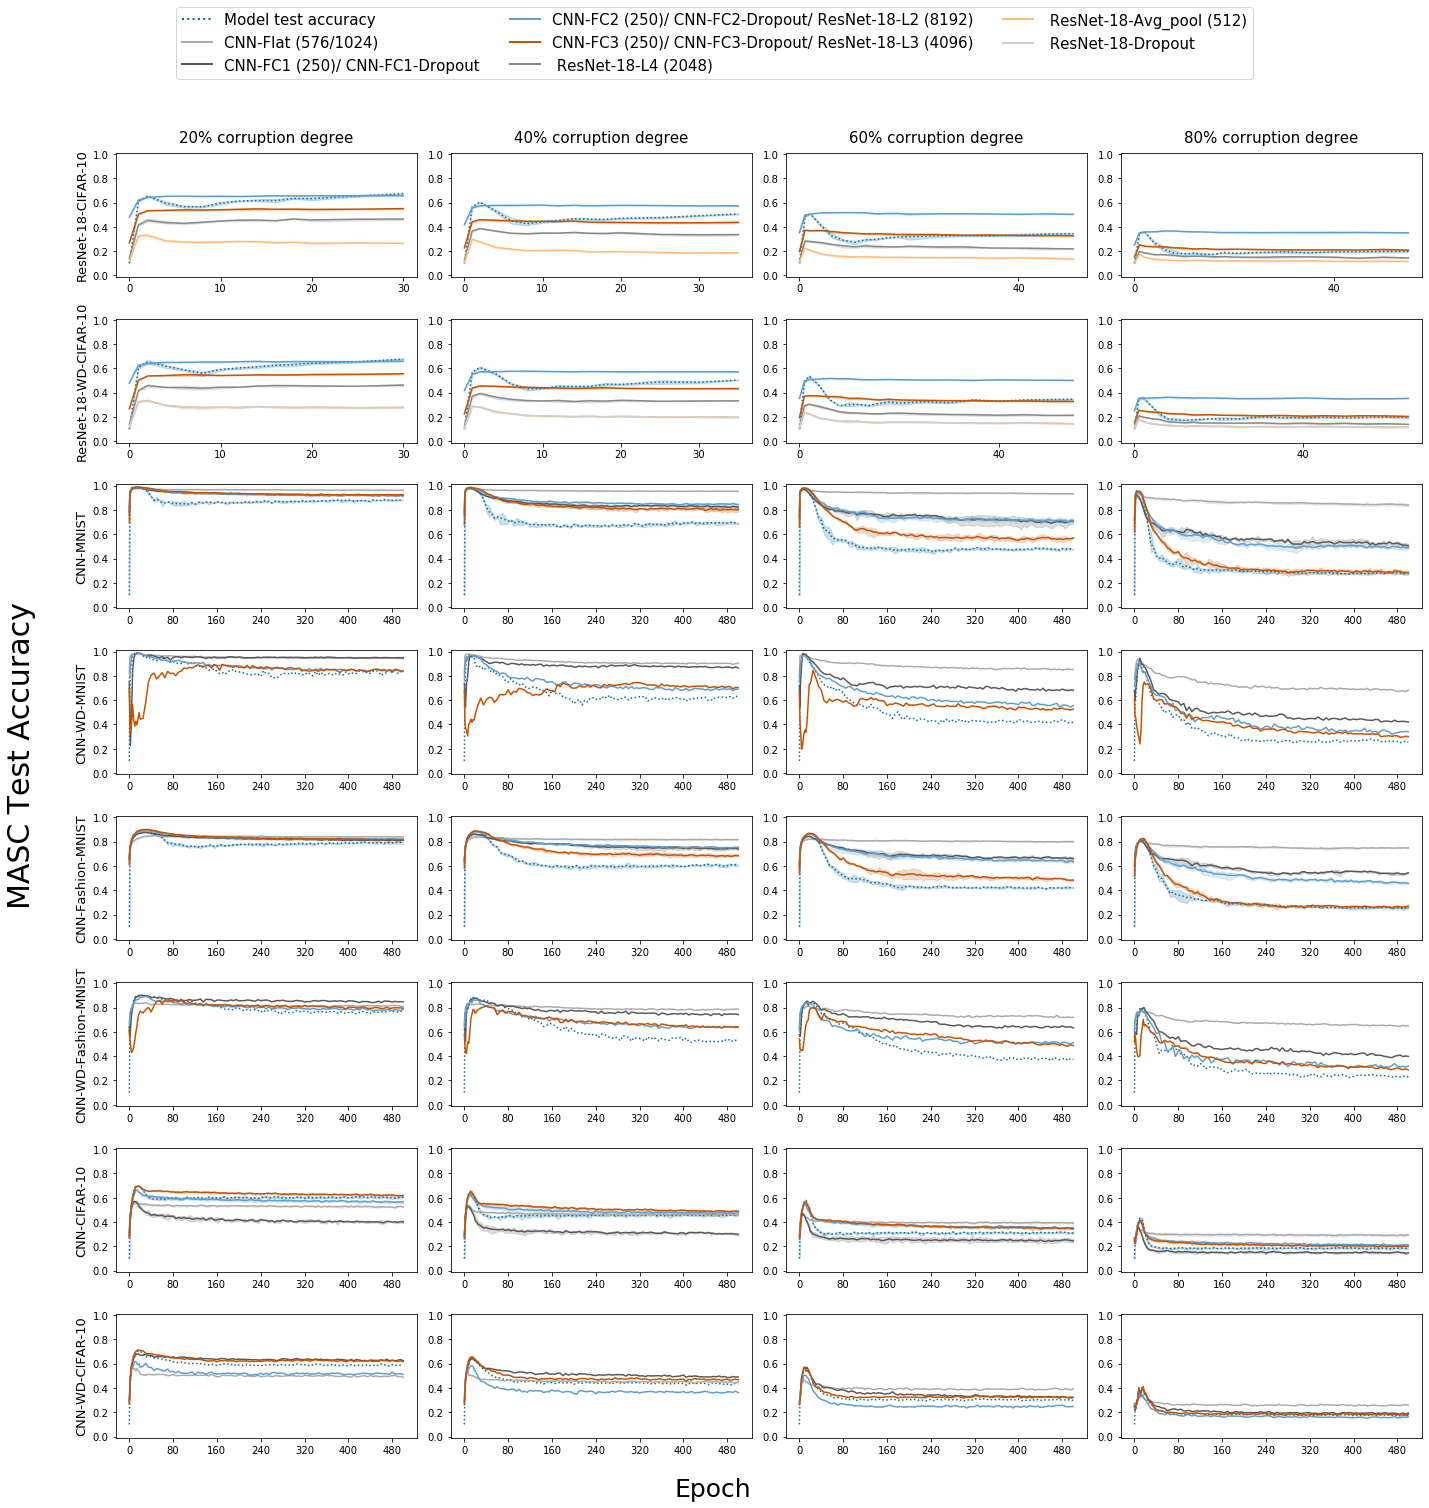

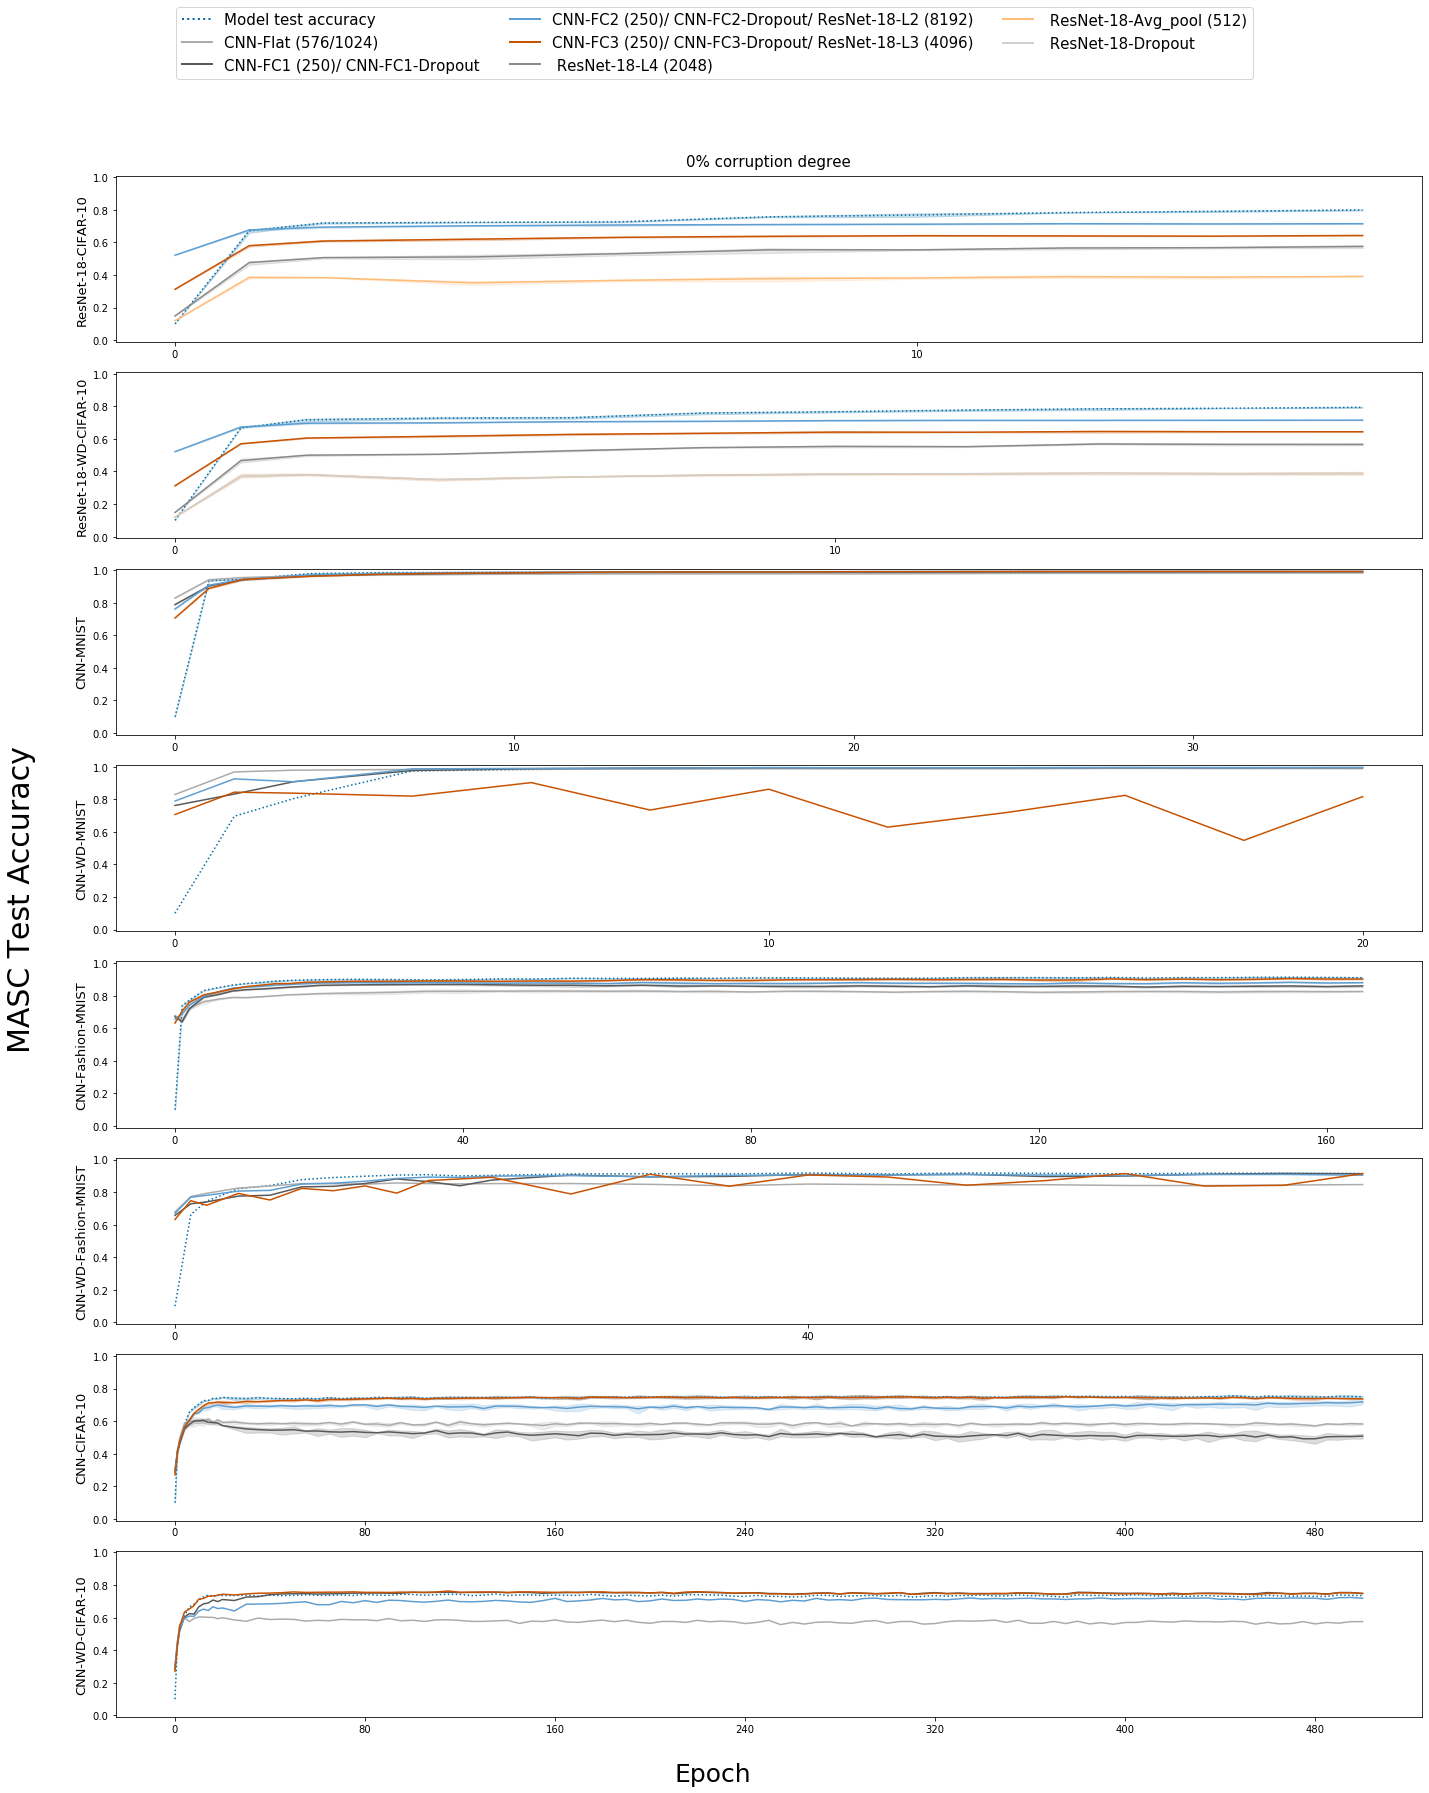

In [14]:
plo=plot_drop()
resfoldername='TMLR_PAPER_PLOTS2'
plo.plot_dropout(resfoldername,masc=True,corruptions=True)
plo.plot_dropout(resfoldername,masc=True,corruptions=False)

../TMLR_ResNet18_during_training/results_velpic/40/angle_results_1/CIFAR10_ResNet18/results_0.2
../TMLR_ResNet18_during_training/results_velpic/40/angle_results_1/CIFAR10_ResNet18/results_0.4
../TMLR_ResNet18_during_training/results_velpic/40/angle_results_1/CIFAR10_ResNet18/results_0.6
../TMLR_ResNet18_during_training/results_velpic/40/angle_results_1/CIFAR10_ResNet18/results_0.8
../TMLR_Dropout/results_velpic/40/angle_results_1/CIFAR10_ResNet18_dropout/results_0.2
../TMLR_Dropout/results_velpic/40/angle_results_1/CIFAR10_ResNet18_dropout/results_0.4
../TMLR_Dropout/results_velpic/40/angle_results_1/CIFAR10_ResNet18_dropout/results_0.6
../TMLR_Dropout/results_velpic/40/angle_results_1/CIFAR10_ResNet18_dropout/results_0.8
../pca_during_training_angle/angle_results_1pc/MNIST_CNN/results_0.2
../pca_during_training_angle/angle_results_1pc/MNIST_CNN/results_0.4
../pca_during_training_angle/angle_results_1pc/MNIST_CNN/results_0.6
../pca_during_training_angle/angle_results_1pc/MNIST_CNN/resu

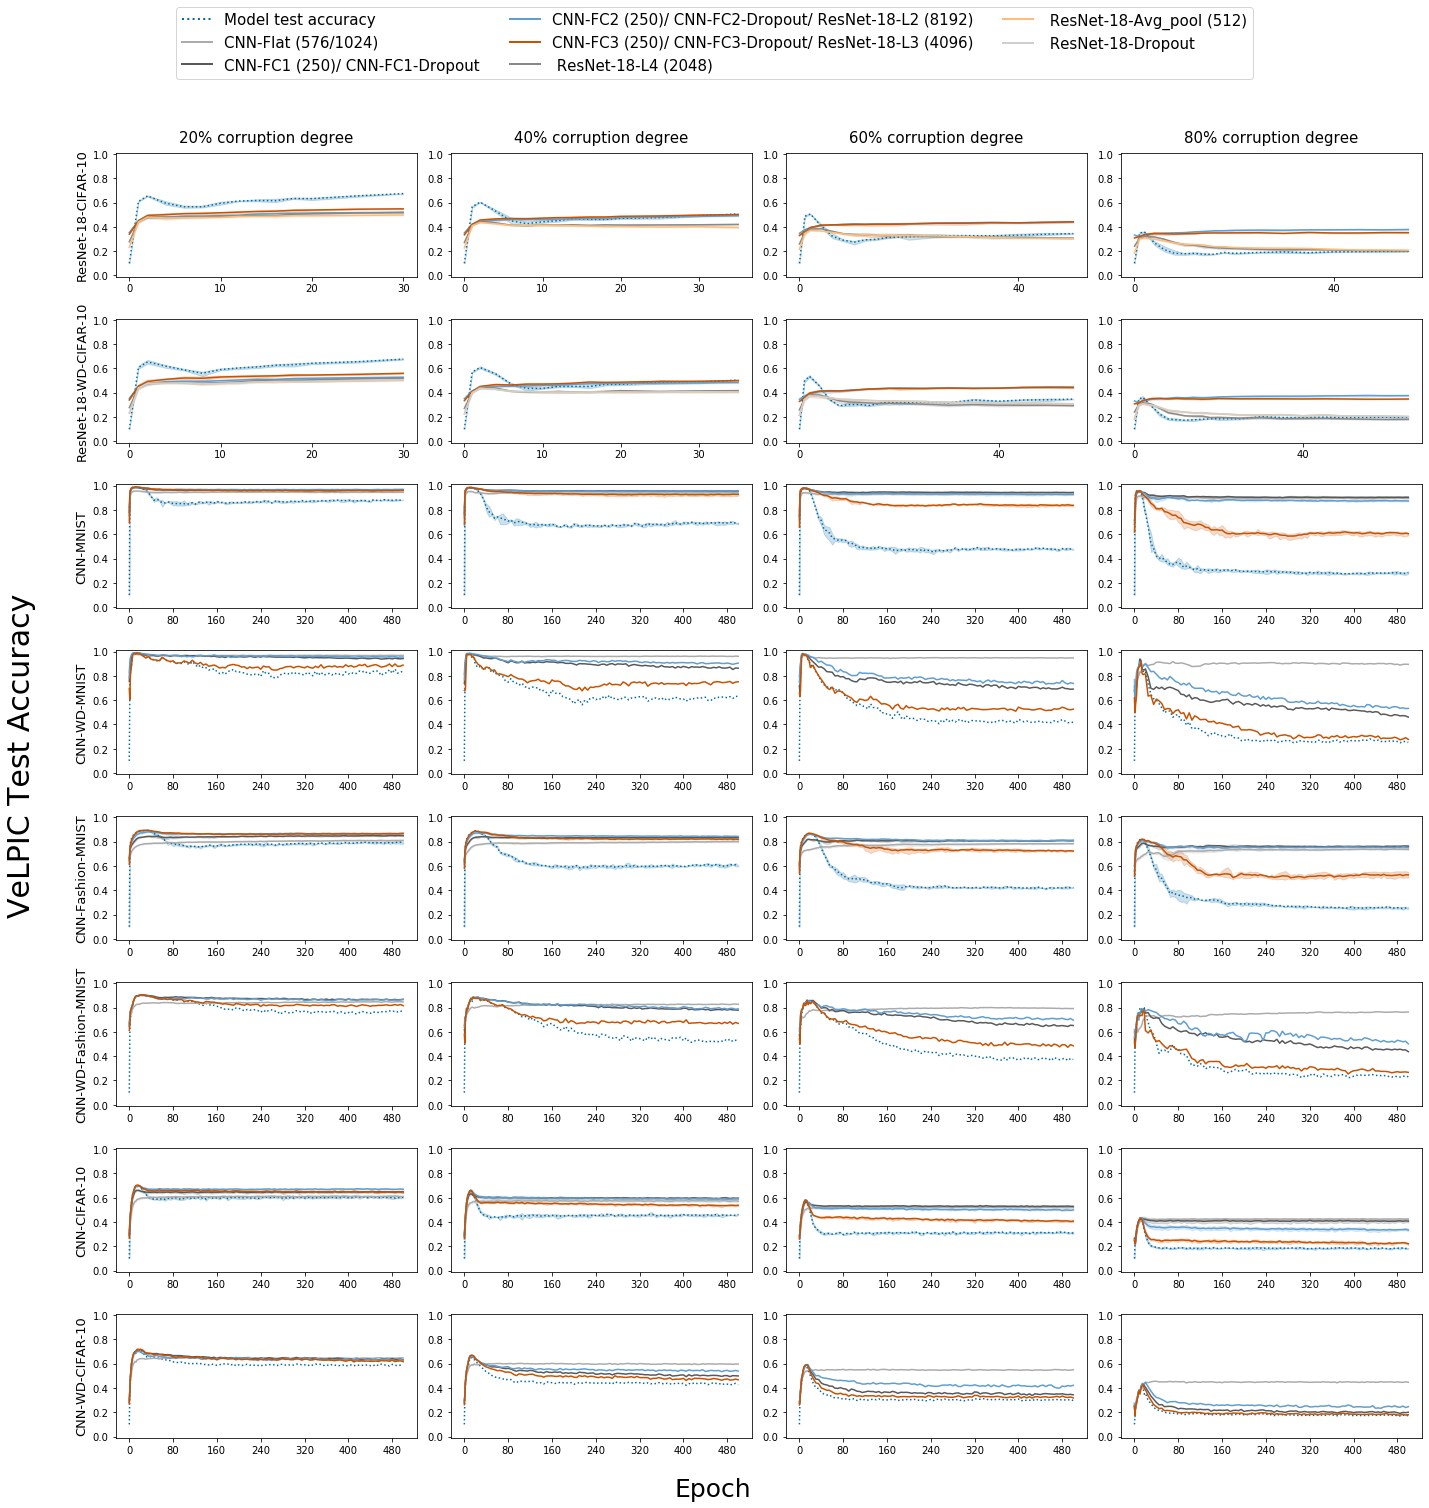

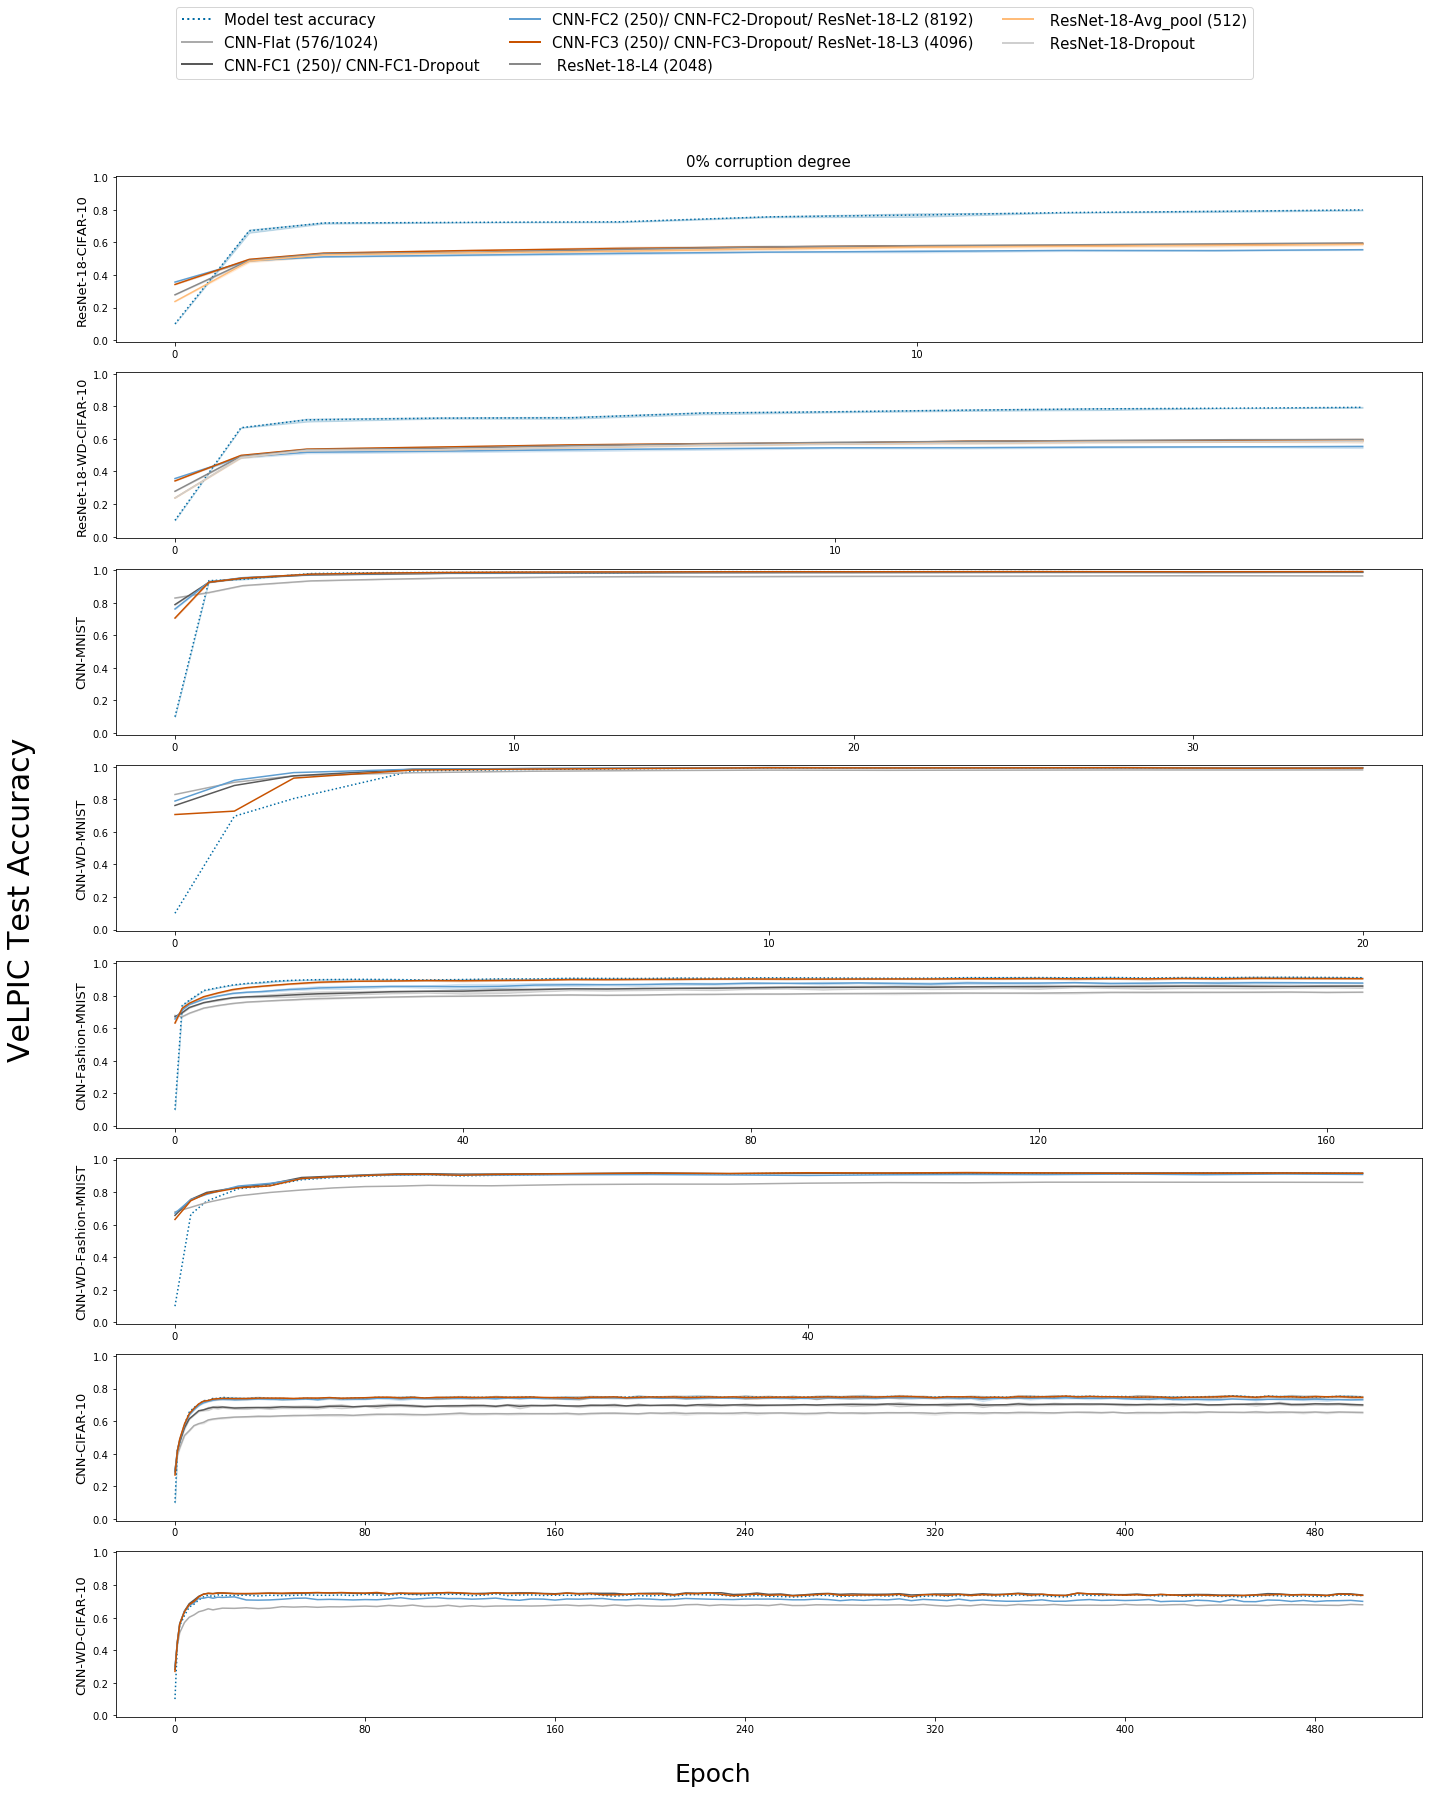

In [5]:
# VeLPIC
plo=plot_drop()
resfoldername='TMLR_PAPER_PLOTS2'
plo.plot_dropout(resfoldername,masc=False,corruptions=True)
plo.plot_dropout(resfoldername,masc=False,corruptions=False)